In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.stats.proportion import proportions_ztest
from scipy.stats import chi2_contingency

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.6f}")

sns.set_theme(style="whitegrid", context="notebook")

print("Imports OK")

Imports OK


In [2]:
df = pd.read_csv("ab_test.csv")

print("Shape:", df.shape)
display(df.head())

Shape: (294478, 5)


,id,time,con_treat,page,converted
0,851104,11:48.6,control,old_page,0
1,804228,01:45.2,control,old_page,0
2,661590,55:06.2,treatment,new_page,0
3,853541,28:03.1,treatment,new_page,0
4,864975,52:26.2,control,old_page,1


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 294478 entries, 0 to 294477
Data columns (total 5 columns):
 #   Column     Non-Null Count   Dtype
---  ------     --------------   -----
 0   id         294478 non-null  int64
 1   time       294478 non-null  str  
 2   con_treat  294478 non-null  str  
 3   page       294478 non-null  str  
 4   converted  294478 non-null  int64
dtypes: int64(2), str(3)
memory usage: 11.2 MB


In [4]:
display(df.describe(include="all"))

,id,time,con_treat,page,converted
count,"294,478.000000",294478,294478,294478,"294,478.000000"
unique,NaN,35993,2,2,NaN
top,NaN,36:26.7,treatment,old_page,NaN
freq,NaN,22,147276,147239,NaN
mean,"787,974.124733",NaN,NaN,NaN,0.119659
std,"91,210.823776",NaN,NaN,NaN,0.324563
min,"630,000.000000",NaN,NaN,NaN,0.000000
25%,"709,032.250000",NaN,NaN,NaN,0.000000
50%,"787,933.500000",NaN,NaN,NaN,0.000000
75%,"866,911.750000",NaN,NaN,NaN,0.000000


In [5]:
print("Missing values:")
display(df.isna().sum())

print("Duplicates:")
print(df.duplicated().sum())

print("Columns:")
print(df.columns.tolist())

Missing values:


id           0
time         0
con_treat    0
page         0
converted    0
dtype: int64

Duplicates:
0
Columns:
['id', 'time', 'con_treat', 'page', 'converted']


# ============================================================
# 1. Создаем рабочую копию данных
# ============================================================

df_clean = df.copy()

print("Original shape:", df.shape)

# ============================================================
# 2. Удаляем пропуски в критичных колонках
# ============================================================
# Эти колонки обязательны для A/B-теста:
# id        — пользователь
# con_treat — группа эксперимента
# page      — страница, которую увидел пользователь
# converted — факт конверсии

critical_cols = ["id", "con_treat", "page", "converted"]

print("Missing values before cleaning:")
display(df_clean[critical_cols].isna().sum())

df_clean = df_clean.dropna(subset=critical_cols).copy()

print("Shape after dropping missing critical values:", df_clean.shape)

# ============================================================
# 3. Удаляем полные дубликаты строк
# ============================================================
# Полные дубликаты искусственно увеличивают размер выборки.

print("Full duplicates before cleaning:", df_clean.duplicated().sum())

df_clean = df_clean.drop_duplicates().copy()

print("Full duplicates after cleaning:", df_clean.duplicated().sum())
print("Shape after dropping full duplicates:", df_clean.shape)

# ============================================================
# 4. Проверяем пользователей, попавших в несколько групп
# ============================================================
# Если один user_id есть и в control, и в treatment,
# такой пользователь загрязняет эксперимент.

user_group_counts = (
    df_clean
    .groupby("id")["con_treat"]
    .nunique()
    .reset_index(name="n_groups")
)

users_in_multiple_groups = user_group_counts[
    user_group_counts["n_groups"] > 1
]["id"]

print("Users in multiple groups:", users_in_multiple_groups.nunique())

# ============================================================
# 5. Удаляем пользователей, попавших в несколько групп
# ============================================================

df_clean = df_clean[
    ~df_clean["id"].isin(users_in_multiple_groups)
].copy()

print("Shape after removing users in multiple groups:", df_clean.shape)

# ============================================================
# 6. Проверяем соответствие group-page
# ============================================================
# В корректном эксперименте:
# control   → old_page
# treatment → new_page

print("Group-page table before filtering:")
display(pd.crosstab(df_clean["con_treat"], df_clean["page"]))

# ============================================================
# 7. Удаляем некорректные пары group-page
# ============================================================

df_clean = df_clean[
    ((df_clean["con_treat"] == "control") & (df_clean["page"] == "old_page")) |
    ((df_clean["con_treat"] == "treatment") & (df_clean["page"] == "new_page"))
].copy()

print("Group-page table after filtering:")
display(pd.crosstab(df_clean["con_treat"], df_clean["page"]))

print("Shape after group-page filtering:", df_clean.shape)

# ============================================================
# 8. Проверяем повторяющихся пользователей
# ============================================================
# В A/B-тесте единица наблюдения — пользователь.
# Поэтому один пользователь должен быть представлен одной строкой.

duplicated_users_count = df_clean["id"].duplicated().sum()

print("Duplicated user rows before cleaning:", duplicated_users_count)

# ============================================================
# 9. Оставляем одну запись на пользователя
# ============================================================

df_clean = df_clean.drop_duplicates(subset=["id"], keep="first").copy()

print("Duplicated user rows after cleaning:", df_clean["id"].duplicated().sum())
print("Unique users:", df_clean["id"].nunique())
print("Final clean shape:", df_clean.shape)

# ============================================================
# 10. Финальная проверка чистого датасета
# ============================================================

print("Missing values:")
display(df_clean[critical_cols].isna().sum())

print("Group counts:")
display(df_clean["con_treat"].value_counts())

print("Page counts:")
display(df_clean["page"].value_counts())

print("Converted counts:")
display(df_clean["converted"].value_counts())

print("Final group-page table:")
display(pd.crosstab(df_clean["con_treat"], df_clean["page"]))

In [6]:
# Смотрим, сколько наблюдений в каждой экспериментальной группе
display(df["con_treat"].value_counts())

# Смотрим, какие страницы показывались пользователям
display(df["page"].value_counts())

# Проверяем значения целевой переменной
display(df["converted"].value_counts())

con_treat
treatment    147276
control      147202
Name: count, dtype: int64

page
old_page    147239
new_page    147239
Name: count, dtype: int64

converted
0    259241
1     35237
Name: count, dtype: int64

In [7]:
# Строим таблицу соответствия группы и страницы
group_page_table = pd.crosstab(df["con_treat"], df["page"])

display(group_page_table)

page,new_page,old_page
con_treat,,
control,1928,145274
treatment,145311,1965


In [8]:
# Оставляем только корректные пары:
# control должен видеть old_page
# treatment должен видеть new_page

df_clean = df[
    ((df["con_treat"] == "control") & (df["page"] == "old_page")) |
    ((df["con_treat"] == "treatment") & (df["page"] == "new_page"))
].copy()

print("Original shape:", df.shape)
print("Clean shape:", df_clean.shape)

display(pd.crosstab(df_clean["con_treat"], df_clean["page"]))

Original shape: (294478, 5)
Clean shape: (290585, 5)


page,new_page,old_page
con_treat,,
control,0,145274
treatment,145311,0


In [9]:
# Проверяем, есть ли пользователи, которые встречаются больше одного раза
duplicated_users = df_clean[df_clean["id"].duplicated(keep=False)].sort_values("id")

print("Duplicated users:", duplicated_users["id"].nunique())

display(duplicated_users.head(20))

Duplicated users: 1


,id,time,con_treat,page,converted
1899,773192,37:58.8,treatment,new_page,0
2893,773192,55:59.6,treatment,new_page,0


In [10]:
df_clean = df_clean.drop_duplicates(subset=["id"], keep="first").copy()

print("Duplicated user rows after cleaning:", df_clean["id"].duplicated().sum())
print("Unique users:", df_clean["id"].nunique())
print("Final clean shape:", df_clean.shape)

Duplicated user rows after cleaning: 0
Unique users: 290584
Final clean shape: (290584, 5)


In [11]:
duplicated_users = df_clean[df_clean["id"].duplicated(keep=False)].sort_values("id")

print("Duplicated users:", duplicated_users["id"].nunique())

display(duplicated_users.head(20))

Duplicated users: 0


,id,time,con_treat,page,converted


In [12]:
# ============================================================
# 11. Считаем conversion rate по группам
# ============================================================
# Conversion Rate = доля пользователей, у которых converted = 1

conversion_summary = (
    df_clean
    .groupby("con_treat")
    .agg(
        users=("id", "nunique"),
        conversions=("converted", "sum"),
        conversion_rate=("converted", "mean")
    )
    .reset_index()
)

conversion_summary["conversion_rate_%"] = conversion_summary["conversion_rate"] * 100

display(conversion_summary)

,con_treat,users,conversions,conversion_rate,conversion_rate_%
0,control,145274,17489,0.120386,12.038630
1,treatment,145310,17264,0.118808,11.880807


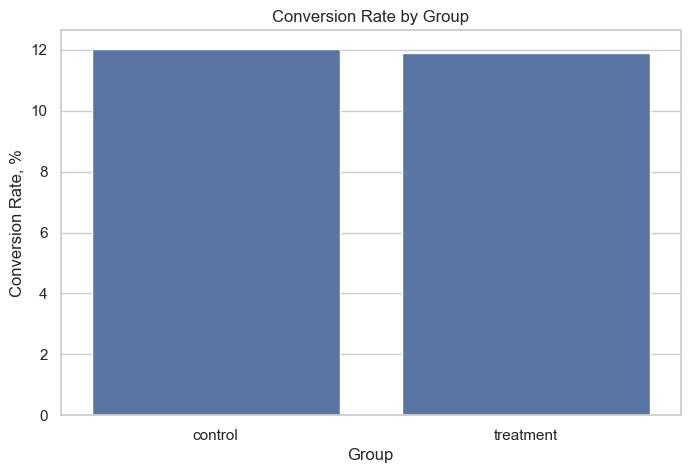

In [13]:
# ============================================================
# 12. Визуализируем conversion rate
# ============================================================

plt.figure(figsize=(8, 5))

sns.barplot(
    data=conversion_summary,
    x="con_treat",
    y="conversion_rate_%"
)

plt.title("Conversion Rate by Group")
plt.xlabel("Group")
plt.ylabel("Conversion Rate, %")
plt.show()

In [14]:
# ============================================================
# 13. Проверяем размеры групп
# ============================================================
# В классическом A/B-тесте группы обычно должны быть примерно равны.
# Если распределение сильно отличается от 50/50, это может быть проблемой эксперимента.

group_sizes = df_clean["con_treat"].value_counts()

display(group_sizes)

control_size = group_sizes["control"]
treatment_size = group_sizes["treatment"]

total_users = control_size + treatment_size

print("Control share:", control_size / total_users)
print("Treatment share:", treatment_size / total_users)

con_treat
treatment    145310
control      145274
Name: count, dtype: int64

Control share: 0.4999380557773312
Treatment share: 0.5000619442226688


In [16]:
# ============================================================
# 15. Гипотезы A/B-теста
# ============================================================
# H0: CR_new = CR_old
# H1: CR_new != CR_old
#
# Так как мы проверяем, изменилась ли конверсия в целом,
# используем two-sided proportions z-test.

control_data = df_clean[df_clean["con_treat"] == "control"]
treatment_data = df_clean[df_clean["con_treat"] == "treatment"]

control_conversions = control_data["converted"].sum()
treatment_conversions = treatment_data["converted"].sum()

control_users = control_data["id"].nunique()
treatment_users = treatment_data["id"].nunique()

count = np.array([treatment_conversions, control_conversions])
nobs = np.array([treatment_users, control_users])

print("Conversions:", count)
print("Users:", nobs)

Conversions: [17264 17489]
Users: [145310 145274]


In [17]:
# ============================================================
# 16. Проводим Z-test для долей
# ============================================================

z_stat, p_value = proportions_ztest(
    count=count,
    nobs=nobs,
    alternative="two-sided"
)

control_cr = control_conversions / control_users
treatment_cr = treatment_conversions / treatment_users

absolute_diff = treatment_cr - control_cr
relative_diff = absolute_diff / control_cr

print("Two-sided proportions Z-test")
print("-" * 50)
print(f"Control CR: {control_cr:.6f}")
print(f"Treatment CR: {treatment_cr:.6f}")
print(f"Absolute difference: {absolute_diff:.6f}")
print(f"Relative difference: {relative_diff:.2%}")
print(f"Z-statistic: {z_stat:.6f}")
print(f"P-value: {p_value:.6f}")
print(f"Statistically significant: {p_value < 0.05}")

Two-sided proportions Z-test
--------------------------------------------------
Control CR: 0.120386
Treatment CR: 0.118808
Absolute difference: -0.001578
Relative difference: -1.31%
Z-statistic: -1.310924
P-value: 0.189883
Statistically significant: False


Интерпретация: новая страница показала конверсию чуть ниже старой, но разница статистически незначима. То есть по текущим данным у нас нет оснований говорить, что новая страница реально изменила конверсию.

In [18]:
# ============================================================
# 17. Доверительный интервал для разницы conversion rate
# ============================================================
# Считаем 95% CI для difference = treatment_cr - control_cr

from statsmodels.stats.proportion import confint_proportions_2indep

ci_low, ci_high = confint_proportions_2indep(
    count1=treatment_conversions,
    nobs1=treatment_users,
    count2=control_conversions,
    nobs2=control_users,
    method="wald"
)

print("95% Confidence Interval for CR difference")
print("-" * 50)
print(f"Difference: {absolute_diff:.6f}")
print(f"95% CI: [{ci_low:.6f}, {ci_high:.6f}]")
print(f"CI includes zero: {ci_low <= 0 <= ci_high}")

95% Confidence Interval for CR difference
--------------------------------------------------
Difference: -0.001578
95% CI: [-0.003938, 0.000781]
CI includes zero: True
